In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Caso de Recorte

In [3]:
from PIL import Image
def resize_image_to_dpi(image_path, target_dpi = 600):
    # Open the image using Pillow
    img = Image.open(image_path)

    # Get the current DPI (dots per inch) of the image
    current_dpi = img.info.get("dpi", (300, 300))

    # Calculate the resize factor
    resize_factor = target_dpi / current_dpi[0]

    # Calculate the new size in pixels
    new_width = int(img.width * resize_factor)
    new_height = int(img.height * resize_factor)

    # Resize the image
    resized_img = img.resize((new_width, new_height), Image.LANCZOS)

    # Set the new DPI
    resized_img.info["dpi"] = (target_dpi, target_dpi)

    # Save the resized image
    return np.array(resized_img)

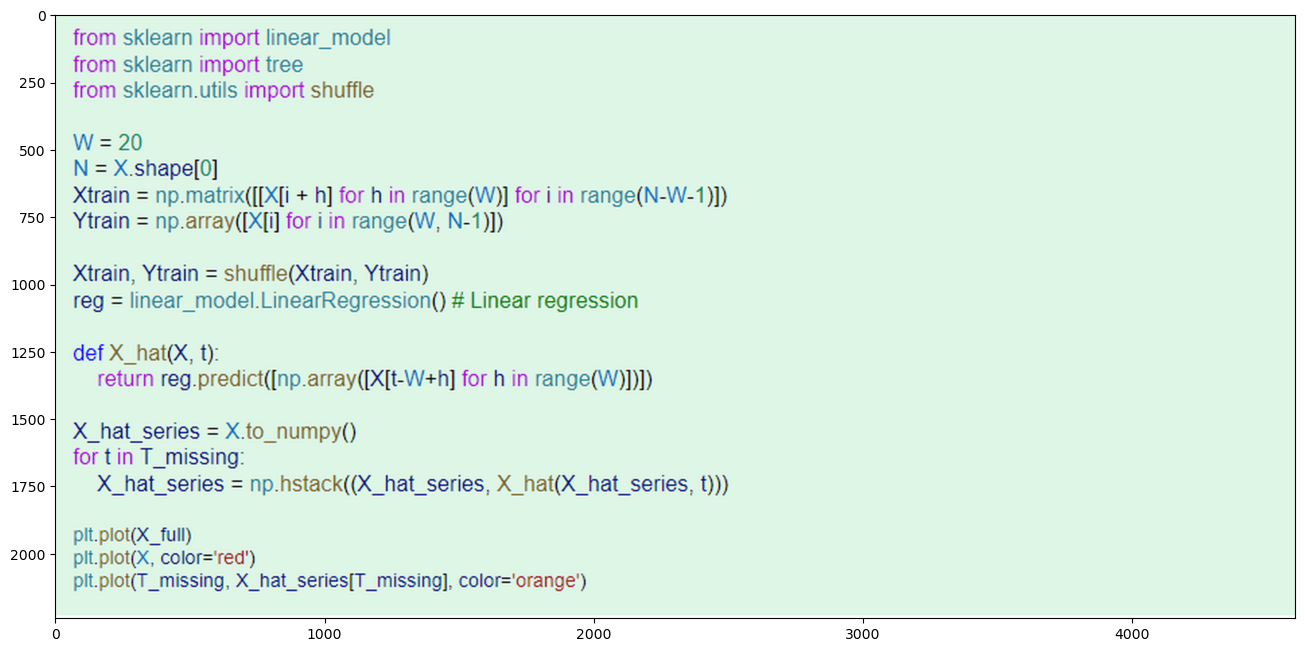

In [4]:

image = resize_image_to_dpi('recorte_python.png')
plt.figure(figsize = (16,8))
plt.imshow(image)

In [5]:
image.shape

(2240, 4605, 4)

In [6]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
scale_percent = (1000 * 100) / min(gray.shape)
width = int(gray.shape[1] * scale_percent / 100)
height = int(gray.shape[0] * scale_percent / 100)
dim = (width, height)
print( scale_percent / 100)
if scale_percent / 100 > 1:
  gray = cv2.resize(gray, dim, interpolation = cv2.INTER_AREA)

if np.mean(gray) > (255 / 2):
  gray = (255-gray)



#blurred = cv2.medianBlur(gray, 3)

# Apply adaptive threshold to handle varying lighting conditions
thresholded = cv2.threshold(gray, 65, 200, cv2.THRESH_BINARY)[1]

0.44642857142857145


In [7]:
thresholded = cv2.copyMakeBorder(thresholded,top =  int(0.05 * thresholded.shape[0]) ,bottom = int(0.05 * thresholded.shape[0]), left = 0, right = 0, borderType = cv2.BORDER_CONSTANT, value = 0)

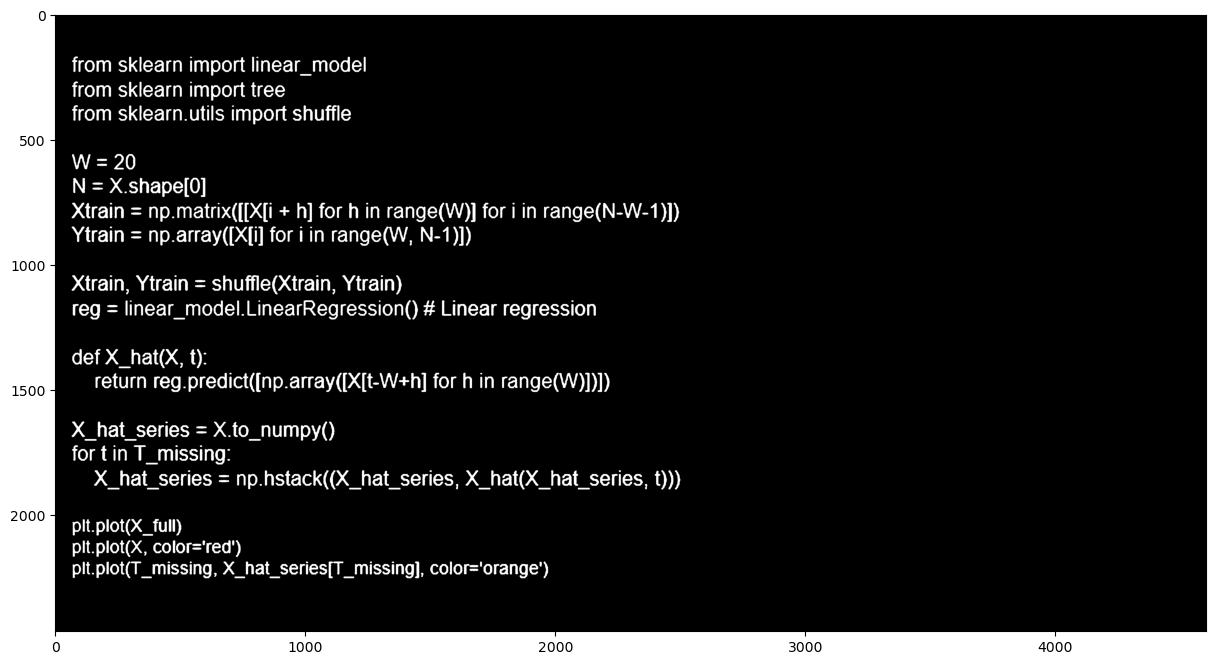

In [8]:
plt.figure(figsize = (16,8))
plt.imshow(thresholded, cmap='gray')

In [9]:
lines = np.sum(thresholded, axis=1)

In [10]:
def find_rois(sums):
    intervalos = []
    inicio_intervalo = None

    for i, valor in enumerate(sums):
        if valor > 0 and inicio_intervalo is None:
            inicio_intervalo = i
        elif valor == 0 and inicio_intervalo is not None:
            intervalos.append((inicio_intervalo, i - 1))
            inicio_intervalo = None

    # Manejo del último intervalo si no termina con un cero
    if inicio_intervalo is not None:
        intervalos.append((inicio_intervalo, len(sums) - 1))

    return intervalos

In [11]:
y_rois = find_rois(lines)


In [12]:
y_rois

[(166, 242),
 (266, 342),
 (361, 437),
 (556, 617),
 (651, 727),
 (750, 828),
 (845, 923),
 (1041, 1117),
 (1141, 1217),
 (1336, 1412),
 (1430, 1508),
 (1626, 1702),
 (1721, 1797),
 (1821, 1897),
 (2016, 2082),
 (2101, 2167),
 (2186, 2252)]

In [13]:
distances = [y_rois[i][0] - y_rois[i-1][1] for i in range(1, len(y_rois))]
limit = min(distances)

In [14]:
limit

17

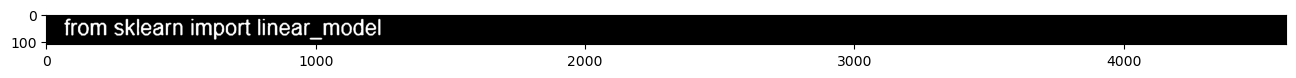

In [15]:
plt.figure(figsize = (16,8))
plt.imshow(thresholded[y_rois[0][0] - limit :y_rois[0][1] + limit, :], cmap='gray')

In [16]:
import pytesseract
pytesseract.pytesseract.tesseract_cmd = r'C:\\Program Files\\Tesseract-OCR\\tesseract'

print(pytesseract.image_to_string(thresholded[y_rois[0][0] - limit :y_rois[0][1] + limit, :]))

from sklearn import linear_model



In [17]:

config = ('-l eng --oem 3 --psm 7')


results = ''.join([pytesseract.image_to_string(thresholded[y_rois[i][0] - limit :y_rois[i][1] + limit, :], config= config) for i in range(len(y_rois))])
print(results)


from sklearn import linear_model
from sklearn import tree
from sklearn.utils import shuffle
W = 20
N = X.shape[0]
Xtrain = np.matrix({[X[i + h] for h in range(W)] for i in range(N-W-1)])
Ytrain = np.array([X[i] for i in range(W, N-1)])
Xtrain, Ytrain = shuffle(Xtrain, Ytrain)
reg = linear_model.LinearRegression() # Linear regression
def X_hat(X, t):
return reg.predict([np.array([X[t-W-+h] for h in range(W)})})
X_hat_series = X.to_numpy()
for tin T_missing:
X_hat_series = np.hstack((X_hat_series, X_hat(X_hat_series, t)))
pit.plot(X_full)
pit.plot(X, color="red’)
pit.plot(T_missing, X_hat_series[T_missing], color='orange’)



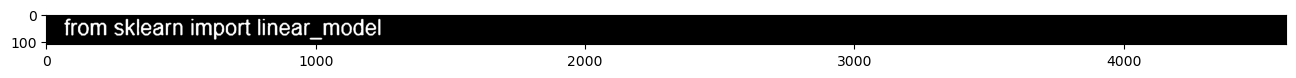

In [18]:
plt.figure(figsize = (16,8))
plt.imshow(thresholded[y_rois[0][0] - limit :y_rois[0][1] + limit, :], cmap='gray')

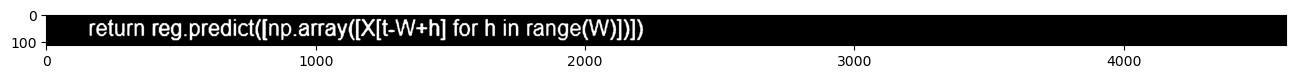

In [19]:
plt.figure(figsize = (16,8))
plt.imshow(thresholded[y_rois[10][0] - limit :y_rois[10][1] + limit, :], cmap='gray')

In [20]:
results[0][0][1]

IndexError: string index out of range

In [ ]:
dist = []
for res in results:
    dist.append(res[0][0][0][0])


In [ ]:
dist

[52, 52, 52, 61, 59, 52, 57, 52, 52, 52, 141, 58, 52, 145, 54, 53, 52]

In [ ]:
print(results[4][0][1])

N = Xshapelo]


'\t4a'

In [70]:
def get_string(results, threshold = 10):
    string = ''
    dist = []
    for res in results:
        if dist == []:
            dist.append(res[0][0][0][0])
            string += res[0][1] + '\n'
        else:
            if res[0][0][0][0] - dist[-1] > threshold:
                string += ''.join(['\t'] * (len(dist) - 1)) + ''.join([res[i][1] for i in range(len(res))]) +'\n'
                dist.append(res[0][0][0][0])
            else:
                i = 0
                while res[0][0][0][0] - dist[i] > threshold:
                    i += 1
                string += ''.join(['\t'] * i) + ''.join([res[i][1] for i in range(len(res))]) +'\n'
    return string
print(get_string(results))


from sklearn import linear_
from sklearn import tree
from sklearn.utils import shuffle
W =20
N = Xshapelo]
Xtrain = np matrix([[XIi + h] for h in range(W)] forin range(N-W-1)])
Ytrain =np.array([XIi] for i in range(W, N-1)])
Xtrain; Ytrain = shuffle(Xtrain, Ytrain)
reg = linear_model LinearRegression() # Linear regression
def X_hat(X, t):
return reg predict([np array([XIt-W+h] for h in range(W)])])
Xhat_series = Xto_numpy()
for t in T_missing:
	X_hat_series = np hstack((X_hat_series, X_hat(X_hat_series, t)))
pltplot(X_full)
plt plot(X , color='red')
pltplot(T_missing, X_hat_series[T_missing], color-_'orange')



# Caso de foto

In [94]:
image = resize_image_to_dpi('primes.jpg')
#image = cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
scale_percent = (1000 * 100) / min(gray.shape)
width = int(gray.shape[1] * scale_percent / 100)
height = int(gray.shape[0] * scale_percent / 100)
dim = (width, height)
gray = cv2.resize(gray, dim, interpolation = cv2.INTER_CUBIC)

if np.mean(gray) > (255 / 2):
  gray = (255-gray)


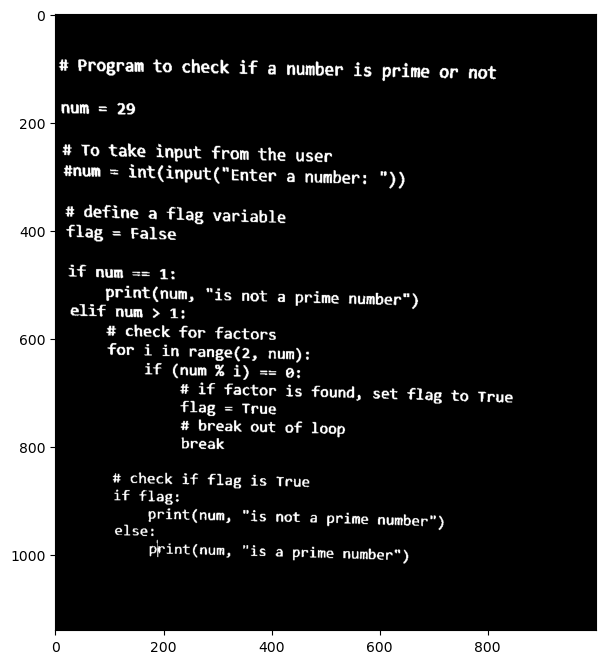

In [95]:
# theshold gray scale image with a lot of noise for ocr
thresholded = cv2.threshold(gray, 50, 200, cv2.THRESH_OTSU)[1]

thresholded = cv2.copyMakeBorder(thresholded,top =  int(0.05 * thresholded.shape[0]) ,bottom = int(0.05 * thresholded.shape[0]), left = 0, right = 0, borderType = cv2.BORDER_CONSTANT, value = 0)

plt.figure(figsize = (16,8))
plt.imshow(thresholded, cmap='gray')



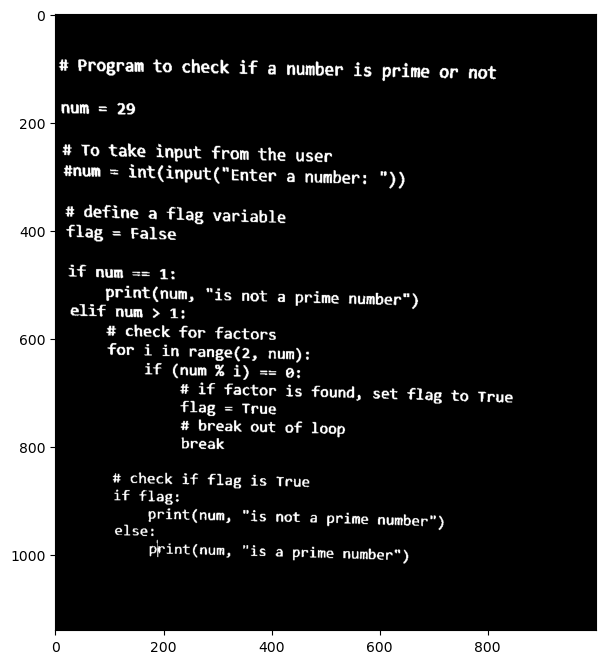

In [96]:
# denoise thresholded using knn
dst = cv2.fastNlMeansDenoising(thresholded, None, 10, 7, 21)

plt.figure(figsize = (16,8))
plt.imshow(dst, cmap='gray')

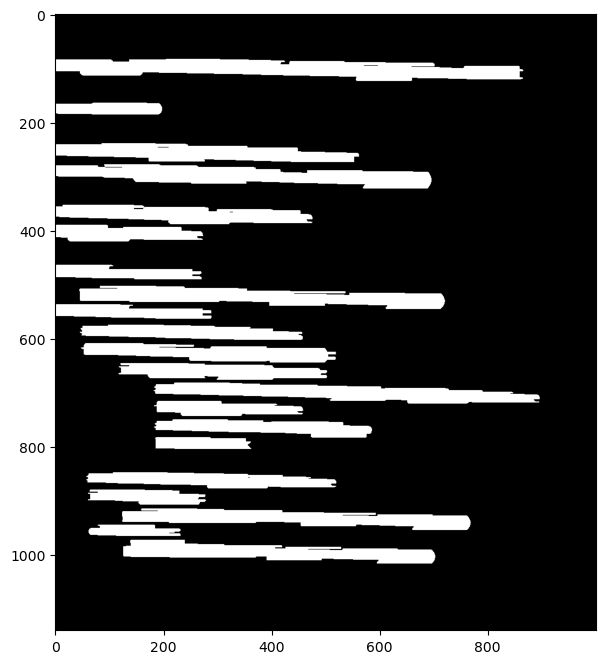

In [97]:
# dilate horizontally to connect text and find rois with lines of text, knowing the shape of the image and adapting to it
kernel = np.ones((1, 100), np.uint8)
dilated = cv2.dilate(dst, kernel, iterations=1)

plt.figure(figsize = (16,8))

plt.imshow(dilated, cmap='gray')




In [98]:
cnts = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = cnts[0] if len(cnts) == 2 else cnts[1]
for c in cnts:
    x,y,w,h = cv2.boundingRect(c)
    ar = w / float(h)
    if ar < 5:
        cv2.drawContours(dilated, [c], -1, (255,255,255), -1)


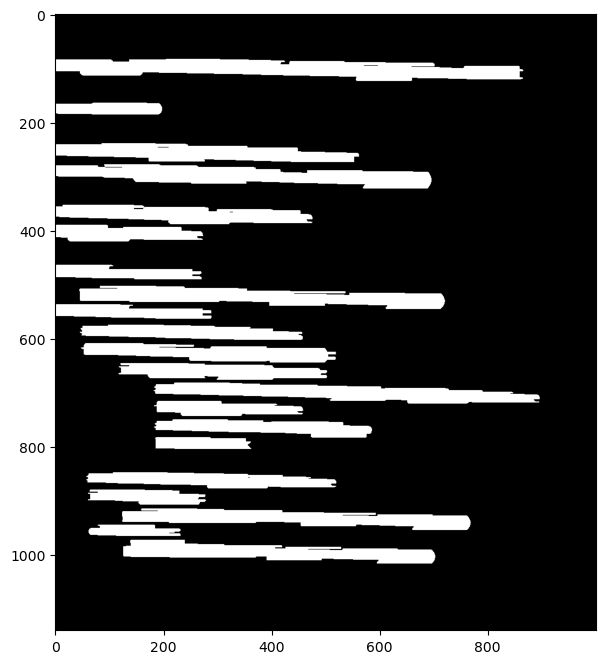

In [99]:
plt.figure(figsize = (16,8))

plt.imshow(dilated, cmap='gray')

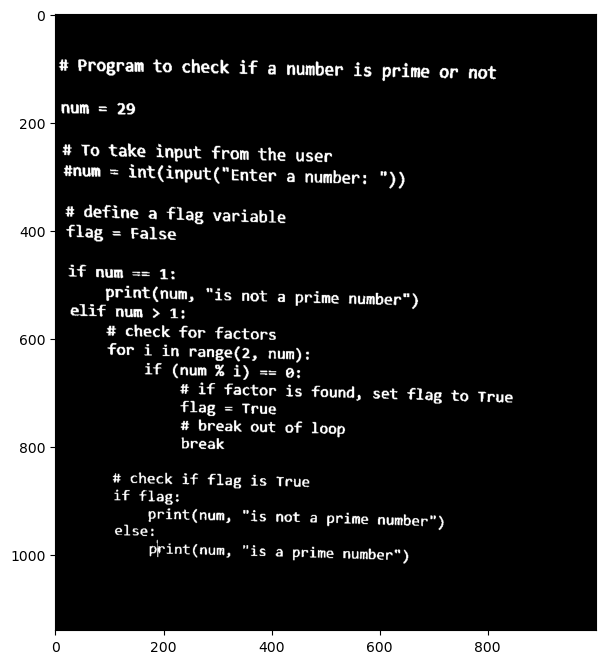

In [100]:
result = cv2.bitwise_and(dilated, dst)
plt.figure(figsize = (16,8))
plt.imshow(result, cmap='gray')

In [101]:
data = pytesseract.image_to_string(result, lang='eng',config='--psm 6')
print(data)

# Program to check if a number is prime or not
num = 29
# To take input from the user
#num = int(input("Enter a number: "))
# define a flag variable
flag = False
if num == 1;
print(num, “is not a prime number")
elif num > 1:
# check for factors
for i in range(2, num):
if (num % i) == @:
# if factor is found, set flag to True
flag = True
# break out of loop
break
# check if flag is True
if flag:
print(num, "is not a prime number")
else:
print (num, "is a prime number")

